In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML # For displaying animations in Colab

def display_replay(frames):
    """
    Displays a list of frames as an animation.
    """
    # Increase figure size for better visibility
    dpi = 72 # Standard DPI for displaying images
    height, width, _ = frames[0].shape
    figsize = width / float(dpi), height / float(dpi)

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    ax.set_axis_off()

    patch = ax.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(frames),
        interval=50
    )
    # Close the plot to prevent it from showing up as a static image
    plt.close()
    # Display the animation in the notebook
    return HTML(anim.to_jshtml())

print("display_replay function defined.")

display_replay function defined.


In [2]:
episode_rewards_history = []
mean_q_history = []
td_loss_history = []
episode_length_history = []
first_episode_frames = []
latest_episode_frames = []
is_first_episode = True

print("Metric and frame capture variables initialized.")

Metric and frame capture variables initialized.


In [3]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing
import numpy as np
import tensorflow as tf
import ale_py # Explicitly import ale_py to ensure Atari environments are registered
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML # For displaying animations in Colab


def display_replay(frames):
    """
    Displays a list of frames as an animation.
    """
    # Increase figure size for better visibility
    dpi = 72 # Standard DPI for displaying images
    height, width, _ = frames[0].shape
    figsize = width / float(dpi), height / float(dpi)

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    ax.set_axis_off()

    patch = ax.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(frames),
        interval=50
    )
    # Close the plot to prevent it from showing up as a static image
    plt.close()
    # Display the animation in the notebook
    return HTML(anim.to_jshtml())


# Install gymnasium[atari] and gymnasium[accept-by-default] to enable Atari environments
!pip install gymnasium[atari] gymnasium[accept-by-default]

# Configuration parameters for the whole setup
seed = 42
gamma = 0.99  # Discount factor for past rewards
epsilon = 1.0  # Epsilon greedy parameter # Fixed typo here
epsilon_min = 0.1  # Minimum epsilon greedy parameter
epsilon_max = 1.0  # Maximum epsilon greedy parameter
epsilon_interval = (
    epsilon_max - epsilon_min
)  # Rate at which to reduce chance of random action being taken
batch_size = 32  # Size of batch taken from replay buffer
max_steps_per_episode = 10000
max_episodes = 10  # Limit training episodes, will run until solved if smaller than 1

# Use the Atari environment
# Specify the `render_mode` parameter to show the attempts of the agent in a pop up window.
env = gym.make("BreakoutNoFrameskip-v4")  # , render_mode="human")
# Environment preprocessing
env = AtariPreprocessing(env)
# Removed FrameStack

num_actions = 4


def create_q_model():
    # Network defined by the Deepmind paper
    return keras.Sequential(
        [
            # The model now receives a single frame of shape (84, 84)
            # Expand dimensions to (84, 84, 1) for Conv2D layers
            layers.Lambda(
                lambda tensor: keras.ops.expand_dims(tensor, axis=-1),
                input_shape=(84, 84),
                output_shape=(84, 84, 1),
            ),
            # Convolutions on the frames on the screen
            layers.Conv2D(32, 8, strides=4, activation="relu"),
            layers.Conv2D(64, 4, strides=2, activation="relu"),
            layers.Conv2D(64, 3, strides=1, activation="relu"),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.Dense(num_actions, activation="linear"),
        ]
    )


# The first model makes the predictions for Q-values which are used to
# make a action.
model = create_q_model()
# Build a target model for the prediction of future rewards.
# The weights of a target model get updated every 10000 steps thus when the
# loss between the Q-values is calculated the target Q-value is stable.
model_target = create_q_model()

# In the Deepmind paper they use RMSProp however then Adam optimizer
# improves training time
optimizer = keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)

# Experience replay buffers
action_history = []
state_history = []
state_next_history = []
rewards_history = []
done_history = []
episode_reward_history = []
running_reward = 0
episode_count = 0
frame_count = 0
# Number of frames to take random action and observe output
epsilon_random_frames = 50000
# Number of frames for exploration
epsilon_greedy_frames = 1000000.0
# Maximum replay length
# Note: The Deepmind paper suggests 1000000 however this causes memory issues
max_memory_length = 100000
# Train the model after 4 actions
update_after_actions = 4
# How often to update the target network
update_target_network = 10000
# Using huber loss for stability
loss_function = keras.losses.Huber()

# Metric collection lists
episode_rewards_history = []
mean_q_history = []
td_loss_history = []
episode_length_history = []

# Frame capture lists
first_episode_frames = []
latest_episode_frames = []
is_first_episode = True

while True:
    observation, _ = env.reset(seed=seed)
    state = np.array(observation)
    episode_reward = 0
    current_episode_frames = []

    for timestep in range(1, max_steps_per_episode):
        frame_count += 1

        # Capture frames
        if is_first_episode:
            first_episode_frames.append(np.expand_dims(state, axis=-1))
        current_episode_frames.append(np.expand_dims(state, axis=-1))

        # Use epsilon-greedy for exploration
        if frame_count < epsilon_random_frames or epsilon > np.random.rand(1)[0]:
            # Take random action
            action = np.random.choice(num_actions)
        else:
            # Predict action Q-values
            # From environment state
            state_tensor = keras.ops.convert_to_tensor(state)
            state_tensor = keras.ops.expand_dims(state_tensor, 0)
            action_probs = model(state_tensor, training=False)
            # Take best action
            action = keras.ops.argmax(action_probs[0]).numpy()

        # Decay probability of taking random action
        epsilon -= epsilon_interval / epsilon_greedy_frames
        epsilon = max(epsilon, epsilon_min)

        # Apply the sampled action in our environment
        state_next, reward, done, _, _ = env.step(action)
        state_next = np.array(state_next)

        episode_reward += reward

        # Save actions and states in replay buffer
        action_history.append(action)
        state_history.append(state)
        state_next_history.append(state_next)
        done_history.append(done)
        rewards_history.append(reward)
        state = state_next

        # Update every fourth frame and once batch size is over 32
        if frame_count % update_after_actions == 0 and len(done_history) > batch_size:
            # Get indices of samples for replay buffers
            indices = np.random.choice(range(len(done_history)), size=batch_size)

            # Using list comprehension to sample from replay buffer
            state_sample = np.array([state_history[i] for i in indices])
            state_next_sample = np.array([state_next_history[i] for i in indices])
            rewards_sample = [rewards_history[i] for i in indices]
            action_sample = [action_history[i] for i in indices]
            done_sample = keras.ops.convert_to_tensor(
                [float(done_history[i]) for i in indices]
            )

            # Build the updated Q-values for the sampled future states
            # Use the target model for stability
            future_rewards = model_target.predict(state_next_sample)
            # Q value = reward + discount factor * expected future reward
            updated_q_values = rewards_sample + gamma * keras.ops.amax(
                future_rewards, axis=1
            )

            # If final frame set the last value to -1
            updated_q_values = updated_q_values * (1 - done_sample) - done_sample

            # Create a mask so we only calculate loss on the updated Q-values
            masks = keras.ops.one_hot(action_sample, num_actions)

            with tf.GradientTape() as tape:
                # Train the model on the states and updated Q-values
                q_values = model(state_sample)

                # Apply the masks to the Q-values to get the Q-value for action taken
                q_action = keras.ops.sum(keras.ops.multiply(q_values, masks), axis=1)
                # Calculate loss between new Q-value and old Q-value
                loss = loss_function(updated_q_values, q_action)

            # Backpropagation
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            # Record mean Q-value and TD loss
            # The `action_probs` variable is only available in the `else` branch of epsilon-greedy
            # which means it's not always defined when this block is executed.
            # Instead, re-predict the q_values for the current state_sample to get mean_q_history.
            q_values_for_mean_q = model(state_sample, training=False)
            mean_q_history.append(keras.ops.mean(keras.ops.amax(q_values_for_mean_q, axis=1)).numpy())
            td_loss_history.append(loss.numpy())


        if frame_count % update_target_network == 0:
            # update the the target network with new weights
            model_target.set_weights(model.get_weights())
            # Log details
            template = "running reward: {:.2f} at episode {}, frame count {}"
            print(template.format(running_reward, episode_count, frame_count))

        # Limit the state and reward history
        if len(rewards_history) > max_memory_length:
            del rewards_history[:1]
            del state_history[:1]
            del state_next_history[:1]
            del action_history[:1]
            del done_history[:1]

        if done:
            break

    # Update running reward to check condition for solving
    episode_rewards_history.append(episode_reward)
    episode_reward_history.append(episode_reward)
    episode_length_history.append(timestep) # Record episode length
    if len(episode_reward_history) > 100:
        del episode_reward_history[:1]
    running_reward = np.mean(episode_reward_history)

    episode_count += 1
    is_first_episode = False
    latest_episode_frames = current_episode_frames # Update latest episode frames

    if running_reward > 40:  # Condition to consider the task solved
        print("Solved at episode {}!".format(episode_count))
        break

    if (
        max_episodes > 0 and episode_count >= max_episodes
    ):  # Maximum number of episodes reached
        print("Stopped at episode {}!".format(episode_count))
        break

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

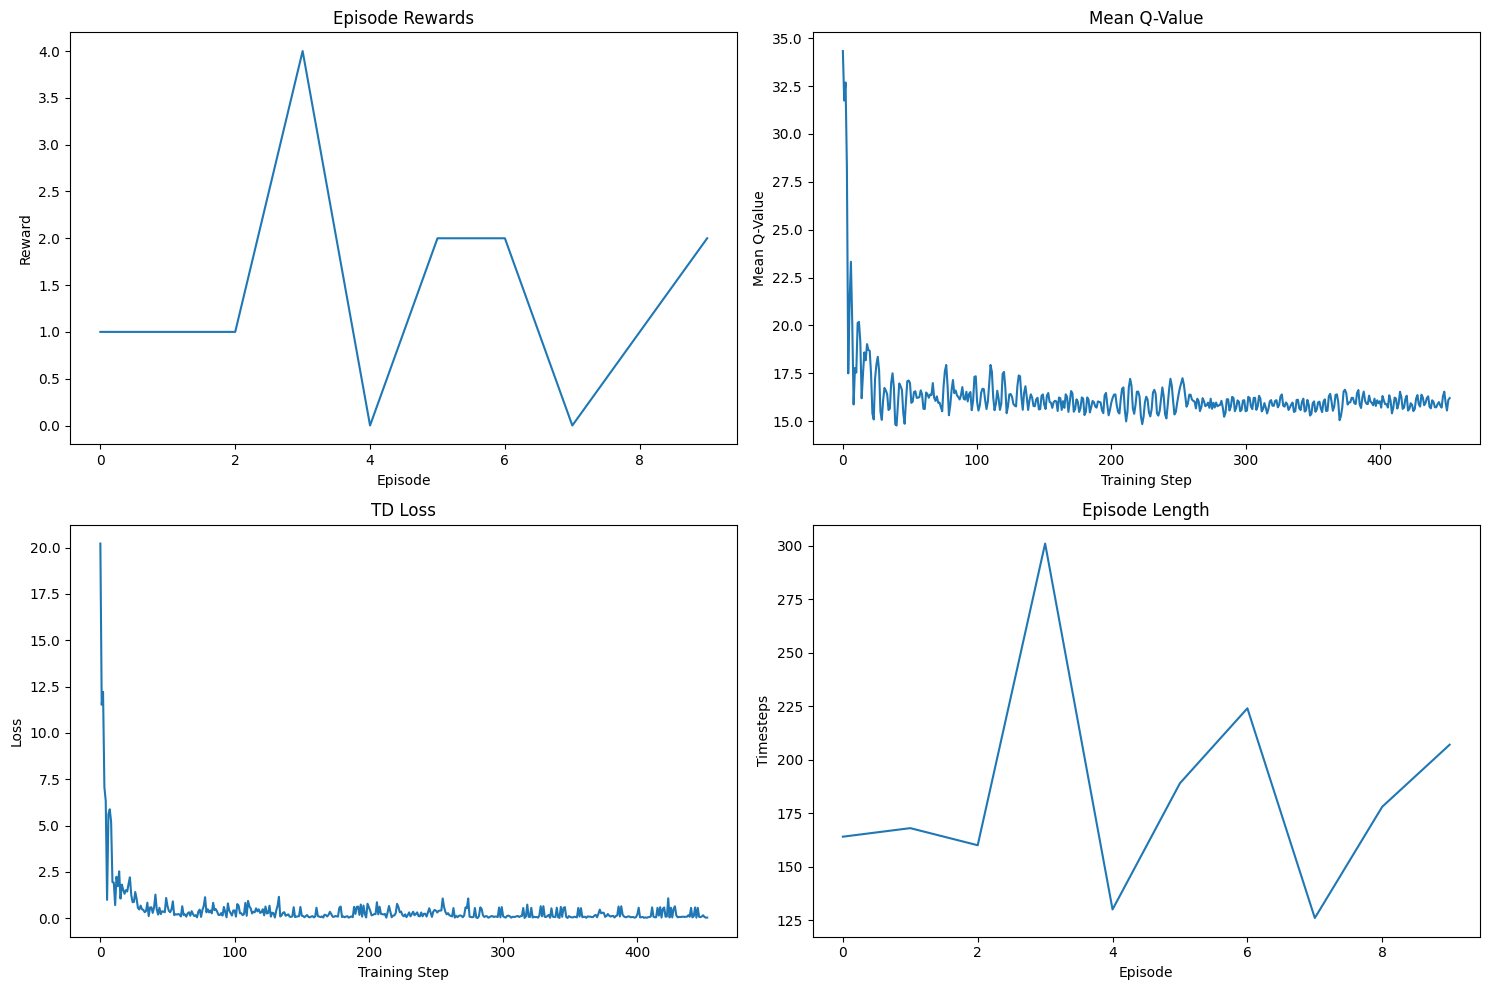

In [4]:
# Plotting metrics
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(episode_rewards_history)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(2, 2, 2)
plt.plot(mean_q_history)
plt.title("Mean Q-Value")
plt.xlabel("Training Step")
plt.ylabel("Mean Q-Value")

plt.subplot(2, 2, 3)
plt.plot(td_loss_history)
plt.title("TD Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.subplot(2, 2, 4)
plt.plot(episode_length_history)
plt.title("Episode Length")
plt.xlabel("Episode")
plt.ylabel("Timesteps")

plt.tight_layout()
plt.show()

In [5]:
# Display replays
print("First episode replay:")
display_replay(first_episode_frames)

First episode replay:


In [6]:
print("Latest episode replay:")
display_replay(latest_episode_frames)

Latest episode replay:
